In [1]:
#hide
from fastbook import *
from fastai.vision.widgets import *

In [2]:
subscription_key = "1e16fe7078f34c868102c3b41c1bb816"
search_term = "grizzly bear"

# From Model to Production

## The Practice of Deep Learning

### Starting Your Project

### The State of Deep Learning

#### Computer vision

#### Text (natural language processing)

#### Combining text and images

#### Tabular data

#### Recommendation systems

#### Other data types

### The Drivetrain Approach

## Gathering Data

# clean
To download images with Bing Image Search, sign up at Microsoft for a free account. You will be given a key, which you can copy and enter in a cell as follows (replacing 'XXX' with your key and executing it):

In [3]:
import requests
import json

# THIS IS WHAT THE COURSE USES
# https://docs.microsoft.com/en-us/azure/cognitive-services/bing-image-search/quickstarts/client-libraries?tabs=visualstudio&pivots=programming-language-python

#REST API
#References
#https://docs.microsoft.com/en-us/bing/search-apis/bing-image-search/quickstarts/rest/python
#https://forums.fast.ai/t/02-production-permissiondenied-error/65823/27
#https://forums.fast.ai/t/getting-the-bing-image-search-key/67417/67
#https://fastcore.fast.ai/#L 
#https://fastcore.fast.ai/foundation.html#L
#https://docs.python.org/3/tutorial/datastructures.html

# Defining function(args) // **kwargs: optional arguments that json.loads takes 
def search_images_bing(subscription_key, search_term, image_count : int = 150, **kwargs):
    
    #API Endpoint
    search_url = "https://api.bing.microsoft.com/v7.0/images/search"
   
    #Create dictionary{key,value}
    headers = {"Ocp-Apim-Subscription-Key" : subscription_key} # azure key
    params  = {"q": search_term, "license" : "public", "imageType" : "photo", "count" : image_count} # search request parameters
   
    #Get request to Bing Image Search API, returns response objects
    response = requests.get(search_url, headers=headers, params = params)
    response.raise_for_status() # Catches if HTTP error occurs 
    search_results = response.json() # Returns json-encoded response
    return L(search_results['value']) #Returns L class, fastcore equivalent to Python lists and numpy

In [4]:
search_images_bing

<function __main__.search_images_bing(subscription_key, search_term, image_count: int = 150, **kwargs)>

In [5]:
# Function call
from IPython.display import Image
from IPython.core.display import HTML 

results = search_images_bing(subscription_key, search_term, min_sz=128)

# Check 150 items were retrieved (contentUrl can be replaced with any key contained in results)
ims = results.attrgot('contentUrl')
len(ims) # 150 should be expected

150

// Sample of JSON object returned
>print(results)<br>{'webSearchUrl': 'https://www.bing.com/images/search?view=detailv2&FORM=OIIRPO&q=grizzly+bear&id=133D334FB509A6FFF0CE879B6C278479C5228B4B&simid=608031914867755973', 
 'name': 'Grizzly Bear in the wild image - Free stock photo - Public ...', 
 'thumbnailUrl': 'https://tse2.mm.bing.net/th?id=OIP.XfVaNeiFQyt0yZe89AD0WQHaE8&pid=Api', 
 'datePublished': '2016-06-30T20:48:00.0000000Z', 
 'isFamilyFriendly': True, 
 'creativeCommons': 'PublicNoRightsReserved', 
 'contentUrl': 'https://www.goodfreephotos.com/albums/animals/mammals/grizzly-bear-in-the-wild.jpg', 
 'hostPageUrl': 'https://www.goodfreephotos.com/animals/mammals/grizzly-bear-in-the-wild.jpg.php', 
 'contentSize': '3579760 B', 
 'encodingFormat': 'jpeg', 
 'hostPageDisplayUrl': 'https://www.goodfreephotos.com/animals/mammals/grizzly-bear-in-the-wild.jpg.php', 
 'width': 5526, 'height': 3684, 
 'hostPageFavIconUrl': 'https://www.bing.com/th?id=ODF.j2vvE0U4IvbfMSjCwWDQ7g&pid=Api', 
 'thumbnail': {'width': 474, 'height': 316}, 
 'imageInsightsToken': 'ccid_XfVaNeiF*cp_EB9C62EC3EA9C7E8811D7294B90EAEF8*mid_133D334FB509A6FFF0CE879B6C278479C5228B4B*simid_608031914867755973*thid_OIP.XfVaNeiFQyt0yZe89AD0WQHaE8', 
 'insightsMetadata': {'recipeSourcesCount': 0, 'pagesIncludingCount': 223, 'availableSizesCount': 115}, 
 'imageId': '133D334FB509A6FFF0CE879B6C278479C5228B4B', 
 'accentColor': '738F3C'},

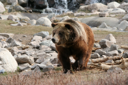

In [6]:
from PIL import Image
# Settings dest to specified local path and opening image
dest = Path('../images/grizzly.jpg')
im = Image.open(dest)
im.to_thumb(128,128)

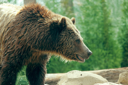

In [7]:
# Checks if dest file exist, if it does removes and replaces. Displays image (should be different than above)
# takes first indexed image url parsed from Bing Image Search API and downloads to destination file
if dest.exists(): os.remove(dest)
download_url(ims[1], dest)
assert dest.exists()
im = Image.open(dest)
im.to_thumb(128,128)

In [11]:
# Specifying sub-directories and directory to store downloaded image search data
bear_types = 'grizzly','black','teddy'
path = Path('bears')

In [12]:
download_images

<function fastai.vision.utils.download_images(dest, url_file=None, urls=None, max_pics=1000, n_workers=8, timeout=4)>

In [13]:
# if folder !exist, create directory, search bing with 'bear_types' bear and download images
# to matching sub-directory
if not path.exists():
    path.mkdir()
    for o in bear_types:
        dest = (path/o) #/bears/grizzly, /bears/black, /bears/teddy
        dest.mkdir(exist_ok=True)
        results = search_images_bing(subscription_key, f'{o} bear')
        download_images(dest, urls=results.attrgot('contentUrl'))

In [14]:
# fastai function to recusrively return image files specified in path
fns = get_image_files(path)
fns

(#450) [Path('bears/grizzly/00000003.jpeg'),Path('bears/grizzly/00000001.jpg'),Path('bears/grizzly/00000000.jpg'),Path('bears/grizzly/00000002.jpg'),Path('bears/grizzly/00000006.jpg'),Path('bears/grizzly/00000009.jpg'),Path('bears/grizzly/00000008.jpg'),Path('bears/grizzly/00000004.jpg'),Path('bears/grizzly/00000007.jpg'),Path('bears/grizzly/00000005.jpg')...]

In [15]:
# fastai function to check all file names are actual images
failed = verify_images(fns)
failed

(#4) [Path('bears/grizzly/00000097.jpg'),Path('bears/grizzly/00000142.png'),Path('bears/black/00000113.jpg'),Path('bears/teddy/00000039.jpg')]

In [16]:
# deleted all failed instances above
failed.map(Path.unlink);

### Sidebar: Getting Help in Jupyter Notebooks

### End sidebar

## From Data to DataLoaders

### DataBlock API

In [17]:
bears = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items = get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(128))

In [ ]:
#Specifying  types for (independent, dependent) variables. 
#Think x (indepdenent) as inputs, and y (dependent) as categories/labels
blocks=(ImageBlock, CategoryBlock)

#Returns a list of images in the specified path
get_items=get_image_files

#Splits data randomly into test and validation sets
#Fix the seed (ensure same starting point) so the same list is returned each time
splitter=RandomSplitter(valid_pct=0.2, seed=42)

#Specifies data using parent labels (dependent variables, directory name)
get_y=parent_label

#Call Item transforms to resize each individual item to 128x128-pixel image                                                                                                                                                                                                                                                                                                                                              
item_tfms=Resize(128)

In [18]:
#DataLoaders is a class that provides batches to the GPU
#Includes dls.valid, and dls.test objects
dls = bears.dataloaders(path)

### Examples of Data Augmentation using item_tfms

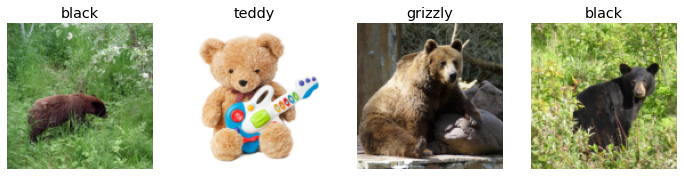

In [19]:
dls.valid.show_batch(max_n=4, nrows=1)

#### Squish/Stretch

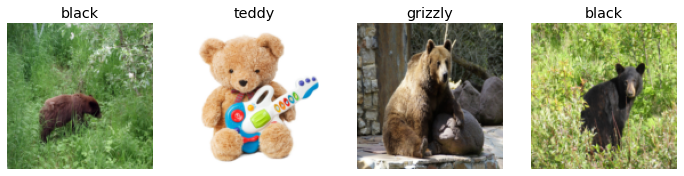

In [20]:
bears = bears.new(item_tfms=Resize(128, ResizeMethod.Squish))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n=4, nrows=1)

#### Padding

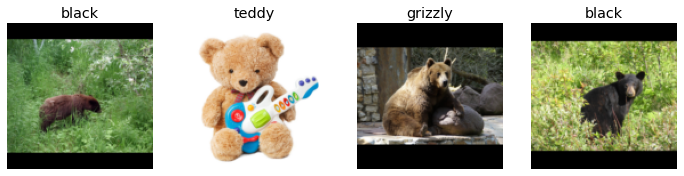

In [21]:
bears = bears.new(item_tfms=Resize(128, ResizeMethod.Pad, pad_mode='zeros'))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n=4, nrows=1)

#### Combination of Crop and Resize (RandomResizedCrop)

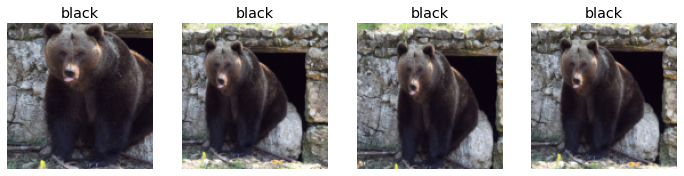

In [22]:
bears = bears.new(item_tfms=RandomResizedCrop(128, min_scale=0.3))
dls = bears.dataloaders(path)
dls.train.show_batch(max_n=4, nrows=1, unique=True)

### Data Augmentation using batch_tfms

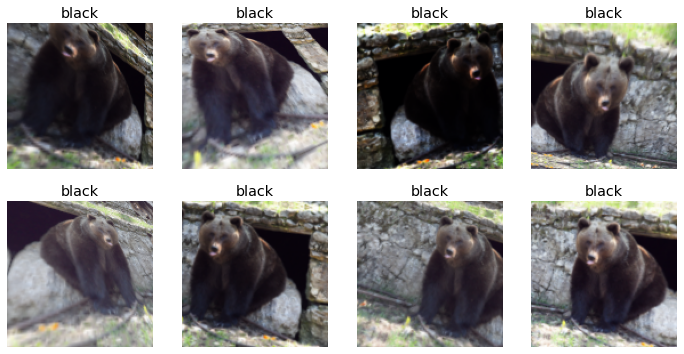

In [23]:
bears = bears.new(item_tfms=Resize(128), batch_tfms=aug_transforms(mult=2))
dls = bears.dataloaders(path)
dls.train.show_batch(max_n=8, nrows=2, unique=True)

## Training Your Model, and Using It to Clean Your Data

In [24]:
bears = bears.new(
    item_tfms=RandomResizedCrop(224, min_scale=0.5),
    batch_tfms=aug_transforms())
dls = bears.dataloaders(path)

In [25]:
learn = cnn_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(4) # Understand fine_tune() more

epoch,train_loss,valid_loss,error_rate,time
0,1.495533,0.245021,0.089888,00:23


epoch,train_loss,valid_loss,error_rate,time
0,0.387173,0.218233,0.078652,00:24
1,0.358140,0.160471,0.078652,00:24
2,0.358176,0.111663,0.056180,00:23
3,0.326370,0.107743,0.056180,00:23


### Confusion Matrix

The confusion matrix below shows that this particular model is having a hard time distinguishing grizzly bears when shown black bears

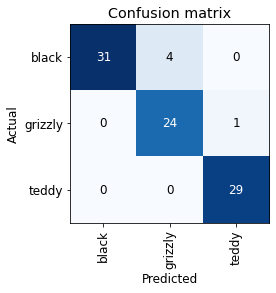

In [26]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()


### Prediction/Label/Loss/Probability

The higher the loss of a prediction means it is incorrect (or confident in its incorrect prediction). plot_top_losses() shows the images with the highest loss in the dataset, the labels printed above the photo are in the header above. The probablity is the confidence level the modal has assigned to its predicton (0 is least confident, 1 is most confident)

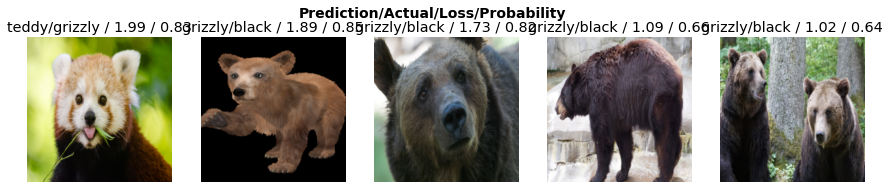

In [27]:
interp.plot_top_losses(5, nrows=1)

### GUI to clean dataset

In [28]:
cleaner = ImageClassifierCleaner(learn)
cleaner

In [31]:
#hide
for idx in cleaner.delete(): cleaner.fns[idx].unlink()
#for idx,cat in cleaner.change(): shutil.move(str(cleaner.fns[idx]), path/cat)

## Turning Your Model into an Online Application

### Using the Model for Inference

A trained model consists of two parts: the architechture and trained parameters. Once a trained model is deployed and used for prediction, it is called an <em>inference model</em>.

fastai saves a file called 'export.pkl' containing the two parts mentioned earlier when learner.export() is called

In [32]:
learn.export()

In [33]:
path = Path()
path.ls(file_exts='.pkl')

(#1) [Path('export.pkl')]

Creating inference learner using load_learner()

In [34]:
learn_inf = load_learner(path/'export.pkl')

Predicting on a single image (use load_learner.predict).

In [35]:
learn_inf.predict('../images/grizzly.jpg')

('grizzly', TensorImage(1), TensorImage([5.3305e-03, 9.9463e-01, 4.1040e-05]))

Returns predicted, index of predicted category, probabilites of EACH (black, grizzly, teddy) category. As seen our 'grizzly.jpg' results in a prediction for that category fairly close to 1.

In [36]:
learn_inf.dls.vocab

['black', 'grizzly', 'teddy']

### Creating a Notebook App from the Model

To create a working web application, IPython widgets and Voila are used. Voila is a system for making applications conistig of Python to be available to end users without using Jupyter at all.

In [39]:
btn_upload = widgets.FileUpload()
btn_upload

FileUpload(value={}, description='Upload')

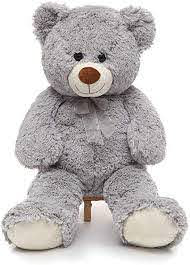

In [41]:
img = PILImage.create(btn_upload.data[-1])
img

In [57]:
out_pl = widgets.Output()
out_pl.clear_output()
out_pl

Output()

In [ ]:
with out_pl: display(img.to_thumb(128,128))

In [43]:
pred,pred_idx,probs = learn_inf.predict(img)

In [58]:
lbl_pred = widgets.Label()
lbl_pred.value = 'Please choose an image... '
lbl_pred

Label(value='Please choose an image... ')

In [45]:
btn_run = widgets.Button(description='Classify')
btn_run

Button(description='Classify', style=ButtonStyle())

In [59]:
def on_click_classify(change):
    img = PILImage.create(btn_upload.data[-1])
    out_pl.clear_output()
    with out_pl: display(img.to_thumb(128,128))
    pred,pred_idx,probs = learn_inf.predict(img)
    lbl_pred.value = f'Prediction: {pred}; Probability: {probs[pred_idx]:.04f}'

btn_run.on_click(on_click_classify)

In [60]:
#hide
#btn_upload to a widget for VBox
btn_upload = widgets.FileUpload()
VBox([widgets.Label('Select your bear!'), 
      btn_upload, btn_run, out_pl, lbl_pred])

### Turning Your Notebook into a Real App

In [ ]:
> #hide
# !pip install voila
# !jupyter serverextension enable voila —sys-prefix

### Deploying your app

## How to Avoid Disaster

### Unforeseen Consequences and Feedback Loops

## Get Writing!

## Questionnaire

1. Where do text models currently have a major deficiency?
>Text models generate compelling responses, but are poor at generating <em>correct</em> responses.
1. What are possible negative societal implications of text generation models?
>The ability for a model to generate context-aware, highly compelling respoonses may spread misinformation on a large scale (see 2016 election).
1. In situations where a model might make mistakes, and those mistakes could be harmful, what is a good alternative to automating a process?
>Instead of fully automating the model, make it apart of the process incorporate flags that alert users when important information/data is recognized by the model
1. What kind of tabular data is deep learning particularly good at?
>Time series, data containing natural language, and large cardinality categrocial groupings.
1. What's a key downside of directly using a deep learning model for recommendation systems?
>Difficult for the model to recommend items that are useful to the consumer.
1. What are the steps of the Drivetrain Approach?
>Consider the objective -> What actions must be taken to meet the objective (levers) -> what data must be collected, acquired, or used that will be helpful -> build a model to optimize actions and results to meet objective (how levers influence objective)
1. How do the steps of the Drivetrain Approach map to a recommendation system?
>Objective -> Provide customers with recommendations to increase consumer happiness and overall sales
>Data -> Collect data on related items customers buy
>Model -> Make recommendation/prediction model with collected data
1. Create an image recognition model using data you curate, and deploy it on the web.
> To be done by reader.
1. What is `DataLoaders`?
>A fastcore class that formats data to be passed to the model, returns .train and .valid object to make it suitable for model training. 
1. What four things do we need to tell fastai to create `DataLoaders`?
> <ul>
    <li>What kind of data is being worked with</li>
    <li>How to get the list of items</li>
    <li>How to label those items</li>
    <li>How to create the validation set</li></ul>
1. What does the `splitter` parameter to `DataBlock` do?
>Splits the data randomly into training and validation sets.
1. How do we ensure a random split always gives the same validation set?
>Fix the seed (ensure same starting point) so the same list is returned each time
1. What letters are often used to signify the independent and dependent variables?
>The independent variable is referred to as <em>x</em> and the dependent variable is referred to as <em>y</em>.
1. What's the difference between the crop, pad, and squish/stretch Resize() approaches? When might you choose one over the others?
><ul>
    <li>Crop is the default Resize() method. Removes unwanted areas possibly resulting in the loss of important details</li>
    <li>Pad (pads matrix image's pixels with zeros) adds black area around the image. This results in lower resoultion, empty space and wasted computation for the model.</li>
    <li>Squish/stretch resizes the images leading it to take an unrealistc shape, which helps the model see different variations of the same thing.</li>
    </ul><br>
The resizing method to use depends on the dataset and application, but usually a combination of these methods is usually seen in data augmentation.
1. What is data augmentation? Why is it needed?
>Data augmentation is when random variations are made to the input data so the data "appears" different to the model but its data content remains the same.
1. Provide an example of where the bear classification model might work poorly in production, due to structural or style differences in the training data.
> The bear is far away or partially obstructed, low-resolution/nighttime images are processed, dataset is biased.
1. What is the difference between `item_tfms` and `batch_tfms`?
><ul>
    <li>items_tfms: performs transforms on each individual item</li>
    <li>batch_tfms: performs transforms to a batch of items using GPU</li></ul>
1. What is a confusion matrix?
>An n x n matrix where the diagonal entries correspond to images classified correctly and off-diagonal cells represent incorrectly classified images
1. What does `export` save?
>learn.export() creates a new file (.pkl) which contains the architechture and all the parameters of a model, a predfined program!
1. What is it called when we use a model for getting predictions, instead of training?
>When a model is deployed after training and used for predictions, it becomes an inference model.
1. What are IPython widgets?
>IPython Widgets are GUI components that bring JavaScript and Python functionality into a web browser.
1. When would you use CPU for deployment? When might GPU be better?
><ul>
    <li>Using a CPU for deployment is not uncommon. It makes more sense to deploy on a CPU since parallel processing is as needed (as much), since a single task is usually executed at a time. It is also much cheaper and accessible!</li>
    <li>A GPU may be considered for deployment if the data being processed is large or if large amounts of server requestis are expected on the webpage.</li></ul>
1. What are the downsides of deploying your app to a server, instead of to a client (or edge) device such as a phone or PC?
> The downsides of deploying on a server is the app requires a network connection. Being on a network connection introduces many possible issues, such as latency, overhead, and data privacy/security.
1. What are three examples of problems that could occur when rolling out a bear warning system in practice?
><ul>
    <li>Working with video files, low resolution at that</li>
    <li>Different lighting (day/night)</li>
    <li>Prompt alert system</li>
    <li>Recognizing/distuinguishing objects that may be hard to see within the captured frame.</li></ul>
1. What is "out-of-domain data"?
>Data being inferred upon varies from the data the model is familiar with/trained on.
1. What is "domain shift"?
>Over time the data being collected changes, therefore pivoting the models behavior/use case
1. What are the three steps in the deployment process?
><ol>
    <li>Manual Process (Only human testing, no model involved)</li>
    <li>Limited Scope Deployment (Careful, calculated human supervision)</li>
    <li>Gradual Expansion (Reporting system required, considers all possibe variables)</li></ol>

### Further Research

1. Consider how the Drivetrain Approach maps to a project or problem you're interested in.
1. When might it be best to avoid certain types of data augmentation?
1. For a project you're interested in applying deep learning to, consider the thought experiment "What would happen if it went really, really well?"
1. Start a blog, and write your first blog post. For instance, write about what you think deep learning might be useful for in a domain you're interested in.